In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from concurrent.futures import ThreadPoolExecutor, as_completed
import logging

import warnings
warnings.filterwarnings('ignore')

In [3]:
class TraverseDatasetAnalyzer:
    """Analyze traverse point data from Heat Watch campaigns"""
    
    def __init__(self, data_root):
        self.data_root = Path(data_root)
        self.traverse_data = []
        self.cities = []
        
    def extract_time_period(self, filename):
        """Extract time period from filename (am, af, pm)"""
        filename_lower = filename.lower()
        # Handle various naming conventions based on data-cleaning-processing.md
        if 'am_' in filename_lower:
            return 'am'
        elif 'af_' in filename_lower:
            return 'af'
        elif 'pm_' in filename_lower:
            return 'pm'
        return 'unknown'
    
    def extract_city_name(self, city_dir_name):
        """Clean up city name from directory"""
        # Remove 'Heat Watch ' prefix if present
        city_name = city_dir_name.replace('Heat Watch ', '')
        return city_name

    def load_traverse_shapefile(self, shapefile_path):
        """Load and extract data from traverse shapefile"""
        try:
            gdf = gpd.read_file(shapefile_path)
            
            temp_field = None
            
            # Set column name to compare to
            temp_column = 'temp_f'
            
            # Ensure column name in file matches required temperature column 
            for col_name in gdf.columns:
                if col_name == temp_column:
                    temp_field = col_name
                    break
            
            if temp_field is None:
                print(f"Warning: No temperature field found in {shapefile_path.name}")
                print(f"  Available columns: {list(gdf.columns)}")
                return None
            
            temps = gdf[temp_field].values
            
            valid_temps = temps[
                ~np.isnan(temps) & 
                (temps != -9999) & 
                (temps != -9999.0)
            ]
            
            if len(valid_temps) == 0:
                print(f"Warning: No valid temperatures in {shapefile_path.name}")
                return None
            
            # Calculate nodata statistics
            nodata_count = len(temps) - len(valid_temps)
            nodata_pct = (nodata_count / len(temps) * 100) if len(temps) > 0 else 0
            
            return {
                'gdf': gdf,
                'temp_field': temp_field,
                'point_count': len(gdf),
                'valid_point_count': len(valid_temps),
                'nodata_count': nodata_count,
                'nodata_pct': nodata_pct,
                'temps': valid_temps
            }
            
        except Exception as e:
            print(f"Error loading {shapefile_path}: {e}")
            return None
    
    def load_all_traverses(self):
        """Load all traverse files from all cities"""
        print("Loading traverse data from all cities...")
        
        for city_dir in sorted(self.data_root.iterdir()):
            if not city_dir.is_dir():
                continue
            
            city_name = self.extract_city_name(city_dir.name)
            
            # Find traverses folders based on common patterns
            traverse_folders = list(city_dir.glob('traverses*'))

            # If no specific traverses folder exists, check main directory
            if not traverse_folders:
                traverse_folders = [city_dir]

            # Track processed files to avoid duplicates
            processed_files = set()
            
            for traverse_folder in traverse_folders:
                # Find all shapefiles
                shapefiles = list(traverse_folder.glob('*trav.shp'))
                
                for shp_path in shapefiles:
                    # Skip if already processed
                    if str(shp_path) in processed_files:
                        continue
                    
                    processed_files.add(str(shp_path))
                    time_period = self.extract_time_period(shp_path.name)
                    
                    traverse_info = self.load_traverse_shapefile(shp_path)
                    
                    if traverse_info:
                        temps = traverse_info['temps']
                        
                        self.traverse_data.append({
                            'city': city_name,
                            'time_period': time_period,
                            'filename': shp_path.name,
                            'filepath': str(shp_path),
                            'point_count': traverse_info['point_count'],
                            'valid_point_count': len(temps),
                            'temp_field': traverse_info['temp_field'],
                            'mean_temp': np.mean(temps),
                            'median_temp': np.median(temps),
                            'std_temp': np.std(temps),
                            'min_temp': np.min(temps),
                            'max_temp': np.max(temps),
                            'range_temp': np.max(temps) - np.min(temps),
                            'percentile_25': np.percentile(temps, 25),
                            'percentile_75': np.percentile(temps, 75),
                            'iqr': np.percentile(temps, 75) - np.percentile(temps, 25),
                            'temps': temps,
                            'gdf': traverse_info['gdf']
                        })
                
                # Only check main directory once
                if traverse_folder == city_dir:
                    break
        
        self.df = pd.DataFrame(self.traverse_data)
        print(f"\nLoaded {len(self.df)} traverse files from {self.df['city'].nunique()} cities")
        return self.df


def analyze_point_counts(df):
    """Analyze number of points in each traverse file"""
    print("\n" + "="*80)
    print("TRAVERSE POINT COUNT ANALYSIS")
    print("="*80)
    
    # Overall statistics
    print(f"\nOverall Statistics:")
    print(f"  Total traverse files: {len(df)}")
    print(f"  Total cities: {df['city'].nunique()}")
    print(f"  Mean points per traverse: {df['point_count'].mean():.1f}")
    print(f"  Median points per traverse: {df['point_count'].median():.1f}")
    print(f"  Range: {df['point_count'].min()} to {df['point_count'].max()} points")
    
    # By time period
    print("\n" + "-"*80)
    print("Points by Time Period:")
    time_counts = df.groupby('time_period')['point_count'].agg(['count', 'mean', 'median', 'min', 'max'])
    print(time_counts)
    
    # Cities with most/least points
    print("\n" + "-"*80)
    print("Top 10 Cities by Average Point Count:")
    city_points = df.groupby('city')['point_count'].mean().sort_values(ascending=False)
    print(city_points.head(10))
    
    print("\nBottom 10 Cities by Average Point Count:")
    print(city_points.tail(10))
    
    # Check for cities missing time periods
    print("\n" + "-"*80)
    print("Time Period Coverage by City:")
    coverage = df.groupby('city')['time_period'].apply(lambda x: sorted(x.unique())).to_frame()
    coverage.columns = ['time_periods']
    
    # Count cities by number of time periods
    period_counts = coverage['time_periods'].apply(len).value_counts().sort_index()
    print("\nCities by number of time periods:")
    for count, num_cities in period_counts.items():
        print(f"  {count} time period(s): {num_cities} cities")
    
    # Show cities with incomplete coverage
    incomplete = coverage[coverage['time_periods'].apply(len) < 3]
    if len(incomplete) > 0:
        print(f"\n{len(incomplete)} cities with incomplete time period coverage:")
        for city, row in incomplete.head(10).iterrows():
            print(f"  {city}: {row['time_periods']}")


def analyze_temperature_distributions(df):
    """Analyze temperature distributions across cities and time periods"""
    print("\n" + "="*80)
    print("TEMPERATURE DISTRIBUTION ANALYSIS")
    print("="*80)
    
    # Overall statistics
    print(f"\nOverall Statistics:")
    print(f"  Mean temperature: {df['mean_temp'].mean():.2f}°F")
    print(f"  Median temperature: {df['median_temp'].mean():.2f}°F")
    print(f"  Std deviation: {df['std_temp'].mean():.2f}°F")
    print(f"  Temperature range across all data: {df['min_temp'].min():.2f}°F to {df['max_temp'].max():.2f}°F")
    
    # By time period
    print("\n" + "-"*80)
    print("Temperature Statistics by Time Period:")
    time_stats = df.groupby('time_period')[['mean_temp', 'median_temp', 'std_temp', 'min_temp', 'max_temp']].agg(['mean', 'std'])
    print(time_stats.round(2))
    
    # Warmest/coolest cities
    print("\n" + "-"*80)
    print("Top 10 Warmest Cities (average across all time periods):")
    city_temps = df.groupby('city')['mean_temp'].mean().sort_values(ascending=False)
    for i, (city, temp) in enumerate(city_temps.head(10).items(), 1):
        print(f"  {i}. {city}: {temp:.2f}°F")
    
    print("\nTop 10 Coolest Cities (average across all time periods):")
    for i, (city, temp) in enumerate(city_temps.tail(10).items(), 1):
        print(f"  {i}. {city}: {temp:.2f}°F")
    
    # Temperature variation within cities (across time periods)
    print("\n" + "-"*80)
    print("Temperature Change Throughout Day (AM to PM):")
    city_time = df.groupby(['city', 'time_period'])['mean_temp'].mean().unstack(fill_value=np.nan)
    
    if 'am' in city_time.columns and 'pm' in city_time.columns:
        city_time['am_to_pm_change'] = city_time['pm'] - city_time['am']
        city_time_sorted = city_time.sort_values('am_to_pm_change', ascending=False)
        
        print("\nCities with Largest Temperature Increase (AM to PM):")
        for i, (city, row) in enumerate(city_time_sorted.head(10).iterrows(), 1):
            if not np.isnan(row['am_to_pm_change']):
                print(f"  {i}. {city}: +{row['am_to_pm_change']:.2f}°F (AM: {row['am']:.1f}°F → PM: {row['pm']:.1f}°F)")
        
        print("\nCities with Smallest Temperature Increase (AM to PM):")
        for i, (city, row) in enumerate(city_time_sorted.tail(10).iterrows(), 1):
            if not np.isnan(row['am_to_pm_change']):
                print(f"  {i}. {city}: +{row['am_to_pm_change']:.2f}°F (AM: {row['am']:.1f}°F → PM: {row['pm']:.1f}°F)")
    
    # Within-city temperature variation
    print("\n" + "-"*80)
    print("Cities with Highest Temperature Variation (average std dev):")
    city_std = df.groupby('city')['std_temp'].mean().sort_values(ascending=False)
    for i, (city, std) in enumerate(city_std.head(10).items(), 1):
        print(f"  {i}. {city}: {std:.2f}°F")


def detect_outliers(df):
    """Detect and analyze outliers in temperature data"""
    print("\n" + "="*80)
    print("OUTLIER DETECTION ANALYSIS")
    print("="*80)
    
    outlier_results = []
    
    for idx, row in df.iterrows():
        temps = row['temps']
        city = row['city']
        time_period = row['time_period']
        
        # Method 1: IQR method
        q1 = np.percentile(temps, 25)
        q3 = np.percentile(temps, 75)
        iqr = q3 - q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr
        
        outliers_iqr = temps[(temps < lower_bound) | (temps > upper_bound)]
        
        # Method 2: Z-score method (|z| > 3)
        z_scores = np.abs(stats.zscore(temps))
        outliers_zscore = temps[z_scores > 3]
        
        if len(outliers_iqr) > 0 or len(outliers_zscore) > 0:
            outlier_results.append({
                'city': city,
                'time_period': time_period,
                'total_points': len(temps),
                'outliers_iqr_count': len(outliers_iqr),
                'outliers_iqr_pct': len(outliers_iqr) / len(temps) * 100,
                'outliers_zscore_count': len(outliers_zscore),
                'outliers_zscore_pct': len(outliers_zscore) / len(temps) * 100,
                'mean_temp': row['mean_temp'],
                'std_temp': row['std_temp'],
                'min_temp': row['min_temp'],
                'max_temp': row['max_temp'],
                'outlier_temps': outliers_iqr if len(outliers_iqr) > 0 else outliers_zscore
            })
    
    outlier_df = pd.DataFrame(outlier_results)
    
    if len(outlier_df) > 0:
        print(f"\nFound outliers in {len(outlier_df)} traverse files")
        
        # Sort by percentage of outliers
        outlier_df_sorted = outlier_df.sort_values('outliers_iqr_pct', ascending=False)
        
        print("\n" + "-"*80)
        print("Top 15 Files with Highest Outlier Percentage (IQR method):")
        print("\nCity | Time | Points | Outliers | % | Mean Temp | Std | Range")
        print("-"*80)
        
        for i, row in outlier_df_sorted.head(15).iterrows():
            print(f"{row['city'][:30]:30s} | {row['time_period']:4s} | "
                  f"{row['total_points']:6d} | {row['outliers_iqr_count']:8d} | "
                  f"{row['outliers_iqr_pct']:5.1f}% | {row['mean_temp']:6.1f}°F | "
                  f"{row['std_temp']:5.1f} | {row['min_temp']:.1f}-{row['max_temp']:.1f}°F")
        
        # Unusual temperature readings
        print("\n" + "-"*80)
        print("Files with Extreme Temperature Readings:")
        
        # Very high temps (>130°F)
        extreme_high = outlier_df[outlier_df['max_temp'] > 130]
        if len(extreme_high) > 0:
            print(f"\n  Very High Temperatures (>130°F): {len(extreme_high)} files")
            for i, row in extreme_high.iterrows():
                print(f"    {row['city']} ({row['time_period']}): Max {row['max_temp']:.1f}°F")
        
        # Very low temps (<32°F)
        extreme_low = outlier_df[outlier_df['min_temp'] < 32]
        if len(extreme_low) > 0:
            print(f"\n  Very Low Temperatures (<32°F): {len(extreme_low)} files")
            for i, row in extreme_low.iterrows():
                print(f"    {row['city']} ({row['time_period']}): Min {row['min_temp']:.1f}°F")
        
        # Large temperature range in single traverse
        large_range = outlier_df[outlier_df['max_temp'] - outlier_df['min_temp'] > 30]
        if len(large_range) > 0:
            print(f"\n  Large Temperature Range (>30°F in single traverse): {len(large_range)} files")
            for i, row in large_range.head(10).iterrows():
                temp_range = row['max_temp'] - row['min_temp']
                print(f"    {row['city']} ({row['time_period']}): {temp_range:.1f}°F range ({row['min_temp']:.1f}-{row['max_temp']:.1f}°F)")
    else:
        print("\nNo significant outliers detected using IQR or Z-score methods.")
    
    return outlier_df

def export_results(df, outlier_df, output_dir='./analysis_results'):
    """Export analysis results to CSV files"""
    output_dir = Path(output_dir)
    output_dir.mkdir(exist_ok=True)
    
    # Summary by city
    city_summary = df.groupby('city').agg({
        'point_count': ['mean', 'sum'],
        'mean_temp': 'mean',
        'median_temp': 'mean',
        'std_temp': 'mean',
        'min_temp': 'min',
        'max_temp': 'max',
        'range_temp': 'mean'
    }).round(2)
    city_summary.columns = ['_'.join(col).strip() for col in city_summary.columns.values]
    city_summary.to_csv(output_dir / 'city_summary.csv')
    
    # Summary by time period
    time_summary = df.groupby('time_period').agg({
        'point_count': ['count', 'mean', 'median'],
        'mean_temp': 'mean',
        'mean_temp': ['mean', 'std'],
        'std_temp': 'mean',
        'min_temp': 'min',
        'max_temp': 'max'
    }).round(2)
    time_summary.columns = ['_'.join(col).strip() for col in time_summary.columns.values]
    time_summary.to_csv(output_dir / 'time_period_summary.csv')
    
    # Detailed traverse file information
    df_export = df.drop(columns=['temps', 'gdf'])
    df_export.to_csv(output_dir / 'traverse_file_details.csv', index=False)
    
    # Outlier information
    if len(outlier_df) > 0:
        outlier_export = outlier_df.drop(columns=['outlier_temps'])
        outlier_export.to_csv(output_dir / 'outlier_analysis.csv', index=False)
    
    print(f"\nResults exported to {output_dir}/")
    print(f"  - city_summary.csv")
    print(f"  - time_period_summary.csv")
    print(f"  - traverse_file_details.csv")
    if len(outlier_df) > 0:
        print(f"  - outlier_analysis.csv")

In [ ]:
BASE_DIR = "/groups/LORTIZUR/heat-watch-data/clean/"

data_root = BASE_DIR

# Load all traverse data
analyzer = TraverseDatasetAnalyzer(data_root)
df = analyzer.load_all_traverses()

if len(df) == 0:
    print("No traverse data found! Check your data_root path.")
else:
# Run analyses
    analyze_point_counts(df)
    analyze_temperature_distributions(df)
    outlier_df = detect_outliers(df)

# Export results
export_results(df, outlier_df)

print("\n" + "="*80)
print("ANALYSIS COMPLETE")
print("="*80)

Loading traverse data from all cities...


ERROR 1: PROJ: proj_create_from_database: Open of /home/alawyer2/miniforge/envs/clim-env/share/proj failed



Loaded 269 traverse files from 89 cities

TRAVERSE POINT COUNT ANALYSIS

Overall Statistics:
  Total traverse files: 269
  Total cities: 89
  Mean points per traverse: 22631.4
  Median points per traverse: 19342.0
  Range: 2342 to 81298 points

--------------------------------------------------------------------------------
Points by Time Period:
             count          mean   median   min    max
time_period                                           
af              90  21924.533333  18686.0  2342  75713
am              90  23666.988889  20293.5  2840  81298
pm              89  22298.932584  19342.0  5891  76956

--------------------------------------------------------------------------------
Top 10 Cities by Average Point Count:
city
Houston and Harris County, TX              77576.333333
Oklahoma City, OK                          74617.333333
Johnson County and Wyandotte County, KS    69966.333333
Baltimore, MD                              49270.333333
San Jose and Santa Clara, 

In [6]:
def create_visualizations(df):
    """Create comprehensive visualizations"""
    
    # Set style
    sns.set_style("whitegrid")
    
    # Create figure with subplots
    fig = plt.figure(figsize=(20, 16))
    
    # 1. Point count distribution by time period
    ax1 = plt.subplot(3, 3, 1)
    time_periods = ['am', 'af', 'pm']
    for period in time_periods:
        period_data = df[df['time_period'] == period]['point_count']
        ax1.hist(period_data, alpha=0.6, label=period.upper(), bins=20)
    ax1.set_xlabel('Number of Points')
    ax1.set_ylabel('Frequency')
    ax1.set_title('Distribution of Point Counts by Time Period')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # 2. Temperature distribution by time period
    ax2 = plt.subplot(3, 3, 2)
    df.boxplot(column='mean_temp', by='time_period', ax=ax2)
    ax2.set_xlabel('Time Period')
    ax2.set_ylabel('Mean Temperature (°F)')
    ax2.set_title('Temperature Distribution by Time Period')
    plt.sca(ax2)
    plt.xticks(rotation=0)
    
    # 3. Temperature range (std dev) by time period
    ax3 = plt.subplot(3, 3, 3)
    df.boxplot(column='std_temp', by='time_period', ax=ax3)
    ax3.set_xlabel('Time Period')
    ax3.set_ylabel('Temperature Std Dev (°F)')
    ax3.set_title('Temperature Variation by Time Period')
    plt.sca(ax3)
    plt.xticks(rotation=0)
    
    # 4. Top 15 warmest cities
    ax4 = plt.subplot(3, 3, 4)
    city_temps = df.groupby('city')['mean_temp'].mean().sort_values(ascending=False).head(15)
    city_temps.plot(kind='barh', ax=ax4, color='red')
    ax4.set_xlabel('Mean Temperature (°F)')
    ax4.set_title('Top 15 Warmest Cities')
    ax4.grid(True, alpha=0.3, axis='x')
    
    # 5. Temperature change throughout day
    ax5 = plt.subplot(3, 3, 5)
    city_time = df.groupby(['city', 'time_period'])['mean_temp'].mean().unstack(fill_value=np.nan)
    if 'am' in city_time.columns and 'pm' in city_time.columns:
        city_time['change'] = city_time['pm'] - city_time['am']
        city_time['change'].dropna().sort_values().plot(kind='barh', ax=ax5, color='orange')
        ax5.set_xlabel('Temperature Change AM to PM (°F)')
        ax5.set_title('Temperature Increase Throughout Day')
        ax5.grid(True, alpha=0.3, axis='x')
    
    # 6. Scatter: point count vs temperature range
    ax6 = plt.subplot(3, 3, 6)
    scatter = ax6.scatter(df['point_count'], df['range_temp'], 
                         c=df['time_period'].map({'am': 0, 'af': 1, 'pm': 2}),
                         alpha=0.6, cmap='viridis')
    ax6.set_xlabel('Number of Points')
    ax6.set_ylabel('Temperature Range (°F)')
    ax6.set_title('Point Count vs Temperature Range')
    ax6.grid(True, alpha=0.3)
    cbar = plt.colorbar(scatter, ax=ax6, ticks=[0, 1, 2])
    cbar.ax.set_yticklabels(['AM', 'AF', 'PM'])
    
    # 7. Histogram of all temperatures
    ax7 = plt.subplot(3, 3, 7)
    for period in time_periods:
        period_temps = []
        for temps in df[df['time_period'] == period]['temps']:
            period_temps.extend(temps)
        ax7.hist(period_temps, alpha=0.5, label=period.upper(), bins=50)
    ax7.set_xlabel('Temperature (°F)')
    ax7.set_ylabel('Frequency')
    ax7.set_title('Distribution of All Temperature Readings')
    ax7.legend()
    ax7.grid(True, alpha=0.3)
    
    # 8. Cities with highest temperature variation
    ax8 = plt.subplot(3, 3, 8)
    city_std = df.groupby('city')['std_temp'].mean().sort_values(ascending=False).head(15)
    city_std.plot(kind='barh', ax=ax8, color='purple')
    ax8.set_xlabel('Average Std Dev (°F)')
    ax8.set_title('Cities with Highest Temperature Variation')
    ax8.grid(True, alpha=0.3, axis='x')
    
    # 9. Point count by city (top 15)
    ax9 = plt.subplot(3, 3, 9)
    city_points = df.groupby('city')['point_count'].mean().sort_values(ascending=False).head(15)
    city_points.plot(kind='barh', ax=ax9, color='green')
    ax9.set_xlabel('Average Points per Traverse')
    ax9.set_title('Cities with Most Traverse Points')
    ax9.grid(True, alpha=0.3, axis='x')
    
    plt.tight_layout()
    plt.savefig('traverse_analysis_comprehensive.png', dpi=300, bbox_inches='tight')
    print("\nSaved visualization: traverse_analysis_comprehensive.png")
    plt.show()



Saved visualization: traverse_analysis_comprehensive.png


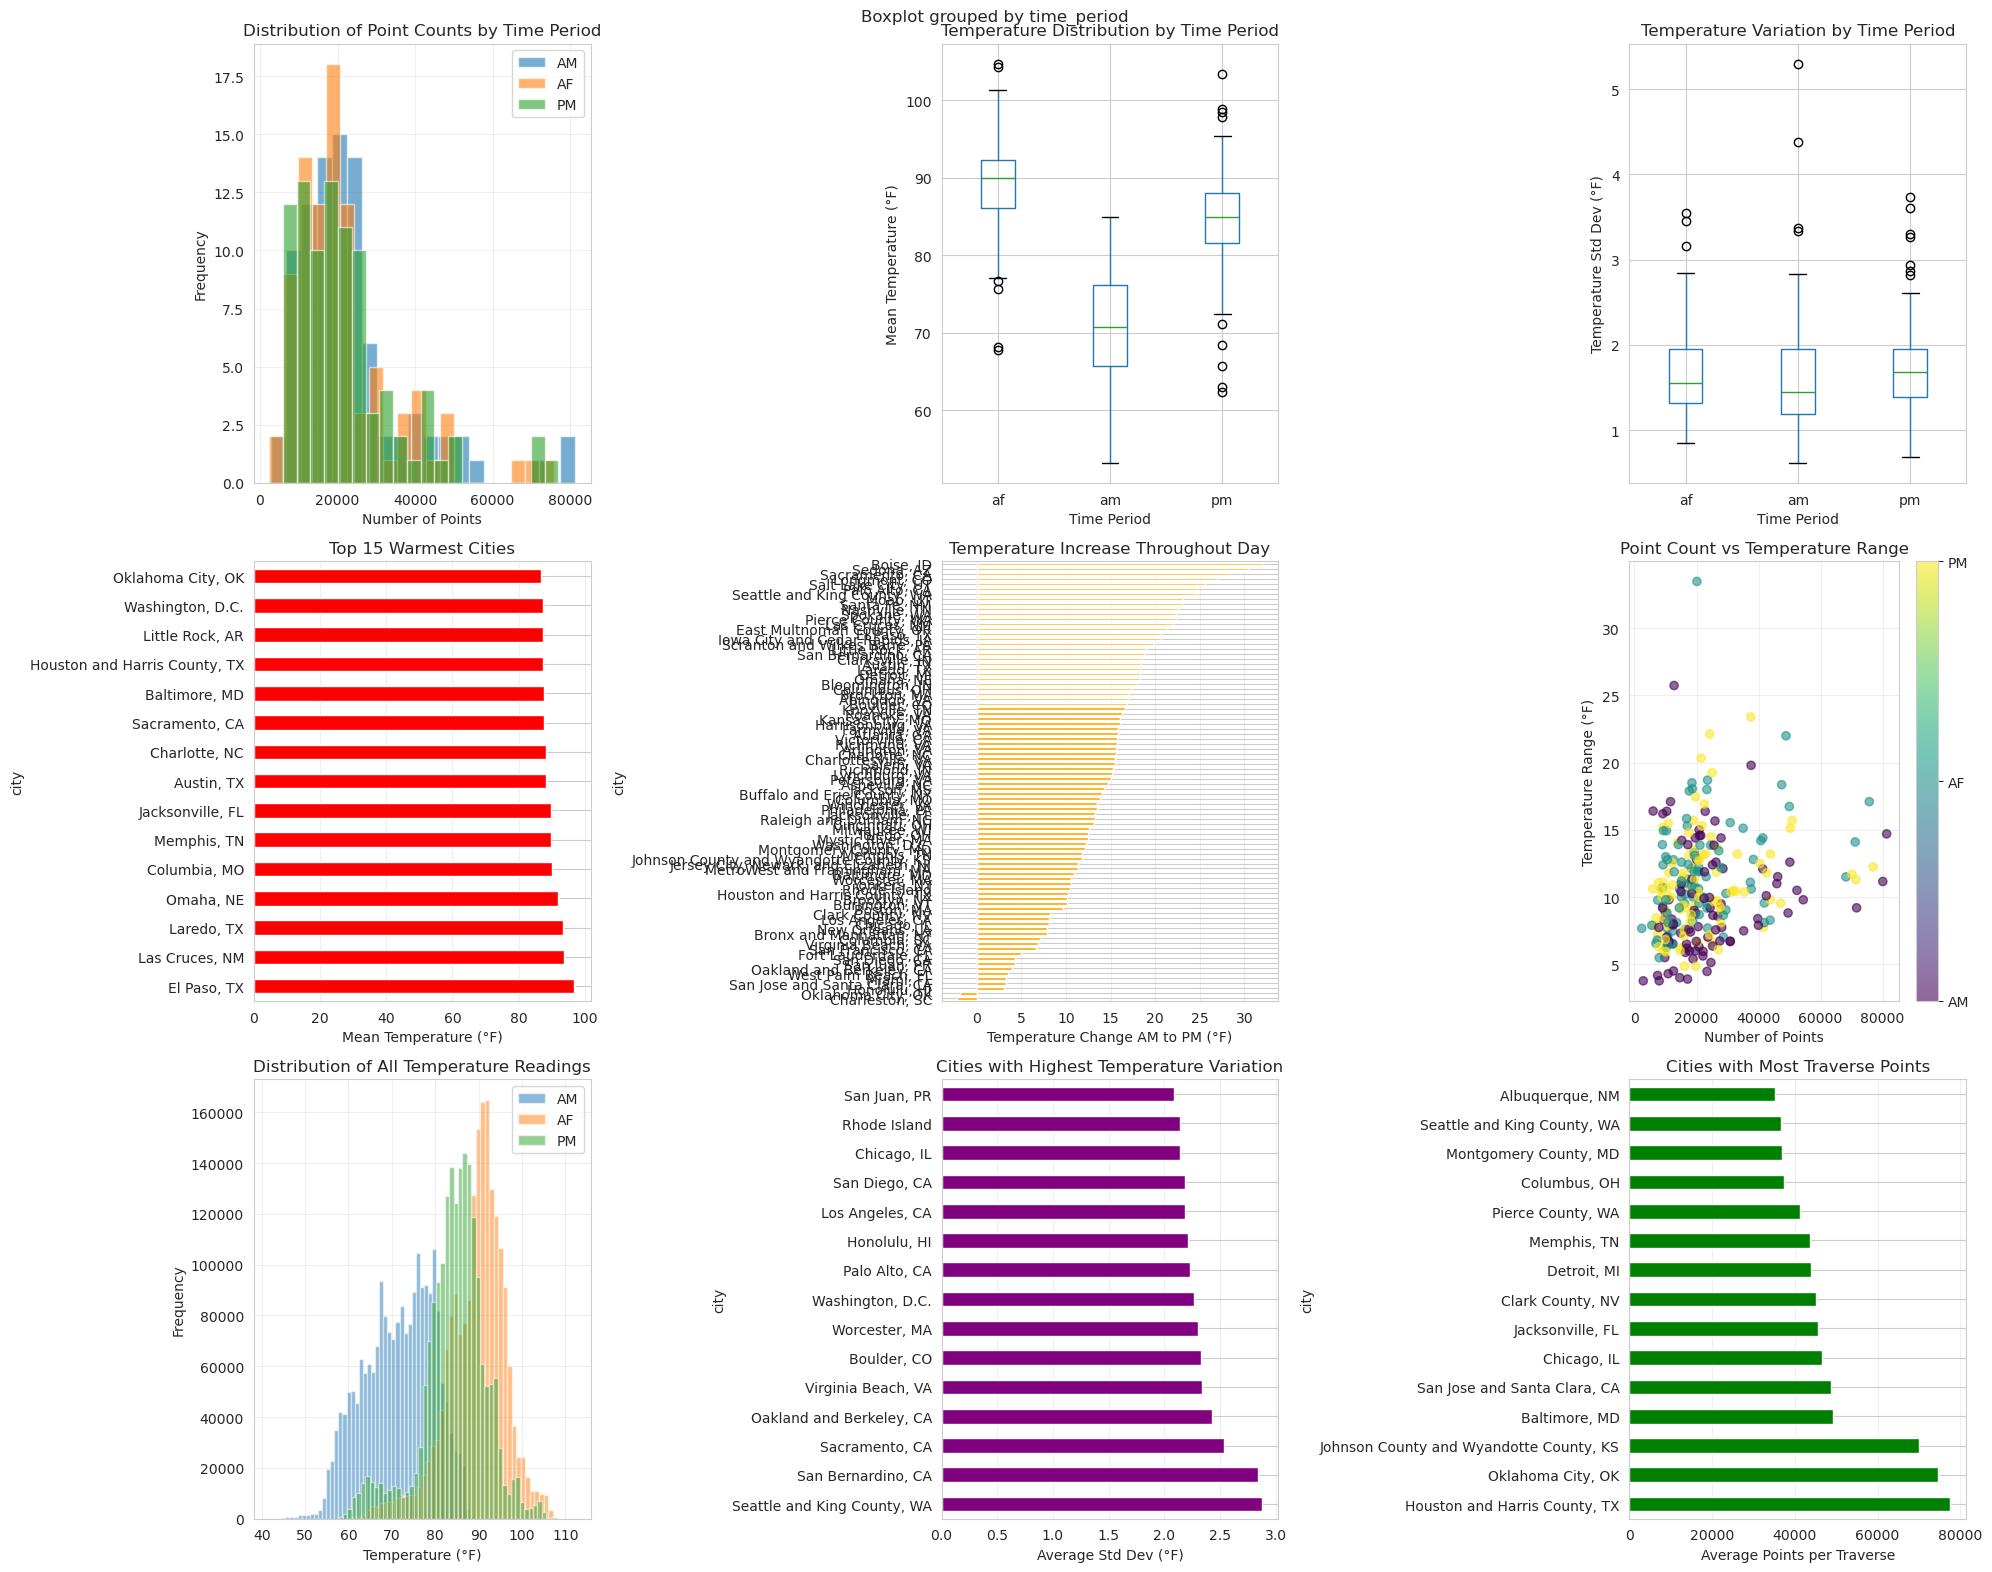

In [7]:
# Create visualizations
create_visualizations(df)